# NSW Electricity Demand & Price Analysis (2020-2026)

**Data Source:** AEMO National Electricity Market (NEM) - Aggregated Price and Demand Data

**Region:** NSW1 (New South Wales)

**Period:** January 2020 to January 2026 (peak summer months, 5-minute resolution)

**Relevance:** January represents peak summer demand in NSW, making it the most critical period for grid planning and infrastructure investment decisions.

---

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\Saadi\OneDrive\Desktop\NSW-Electricity-Demand-Analysis')

# Load all January files
years = [2020, 2021, 2022, 2023, 2024, 2025, 2026]
dfs = []
for y in years:
    path = f'data/PRICE_AND_DEMAND_{y}01_NSW1.csv'
    df = pd.read_csv(path)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df['SETTLEMENTDATE'] = pd.to_datetime(df['SETTLEMENTDATE'])
df['year'] = df['SETTLEMENTDATE'].dt.year
df['hour'] = df['SETTLEMENTDATE'].dt.hour
df['date'] = df['SETTLEMENTDATE'].dt.date

print(f'Total records: {len(df):,}')
print(f'Years covered: {sorted(df["year"].unique())}')
print(f'Columns: {list(df.columns)}')
df.head()

Total records: 47,616
Years covered: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Columns: ['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE', 'year', 'hour', 'date']


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE,year,hour,date
0,NSW1,2020-01-01 00:30:00,7134.15,48.84,TRADE,2020,0,2020-01-01
1,NSW1,2020-01-01 01:00:00,6886.14,50.46,TRADE,2020,1,2020-01-01
2,NSW1,2020-01-01 01:30:00,6682.01,48.73,TRADE,2020,1,2020-01-01
3,NSW1,2020-01-01 02:00:00,6452.46,48.92,TRADE,2020,2,2020-01-01
4,NSW1,2020-01-01 02:30:00,6286.89,49.49,TRADE,2020,2,2020-01-01


## 1. Data Quality Check

In [10]:
print('Missing values:')
print(df[['TOTALDEMAND','RRP']].isnull().sum())
print(f'\nDemand range: {df["TOTALDEMAND"].min():.0f} MW to {df["TOTALDEMAND"].max():.0f} MW')
print(f'Price range:  ${df["RRP"].min():.2f} to ${df["RRP"].max():.2f} /MWh')
# Filter out negative prices and extreme outliers for clean analysis
df_clean = df[(df['RRP'] > -1000) & (df['RRP'] < 15000)].copy()
print(f'\nRecords after cleaning: {len(df_clean):,}')

Missing values:
TOTALDEMAND    0
RRP            0
dtype: int64

Demand range: 4015 MW to 13330 MW
Price range:  $-999.99 to $17500.00 /MWh

Records after cleaning: 47,612


## 2. Year-over-Year Peak Demand Comparison

 year  peak_demand  avg_demand  min_demand
 2020     13330.14 8264.217157     5765.85
 2021     12197.57 7570.487742     5457.08
 2022     11603.27 7623.912866     5604.14
 2023     11035.01 7319.430705     4450.19
 2024     12494.58 7616.089782     4837.19
 2025     12128.62 7228.969546     4188.12
 2026     13146.79 7393.698602     4015.44


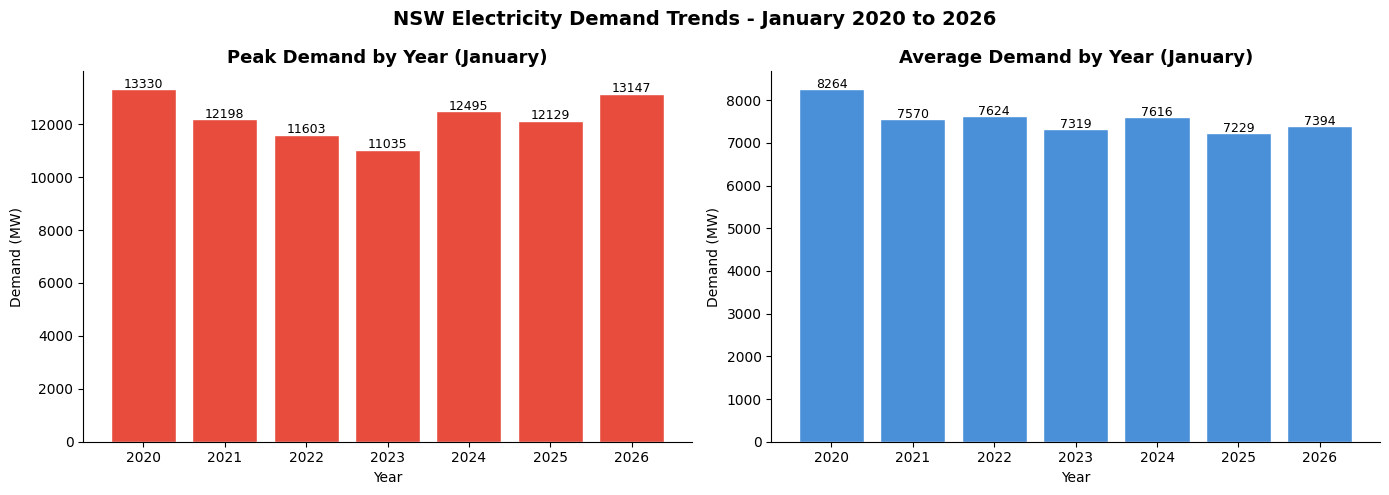

In [11]:
yearly = df_clean.groupby('year').agg(
    peak_demand=('TOTALDEMAND', 'max'),
    avg_demand=('TOTALDEMAND', 'mean'),
    min_demand=('TOTALDEMAND', 'min')
).reset_index()

print(yearly.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yearly['year'], yearly['peak_demand'], color='#e74c3c', edgecolor='white')
axes[0].set_title('Peak Demand by Year (January)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Demand (MW)')
axes[0].set_xlabel('Year')
for i, row in yearly.iterrows():
    axes[0].text(row['year'], row['peak_demand'] + 50, f'{row["peak_demand"]:.0f}', ha='center', fontsize=9)

axes[1].bar(yearly['year'], yearly['avg_demand'], color='#4a90d9', edgecolor='white')
axes[1].set_title('Average Demand by Year (January)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Demand (MW)')
axes[1].set_xlabel('Year')
for i, row in yearly.iterrows():
    axes[1].text(row['year'], row['avg_demand'] + 20, f'{row["avg_demand"]:.0f}', ha='center', fontsize=9)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('NSW Electricity Demand Trends - January 2020 to 2026', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/demand_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Daily Demand Profile - Average Load Shape

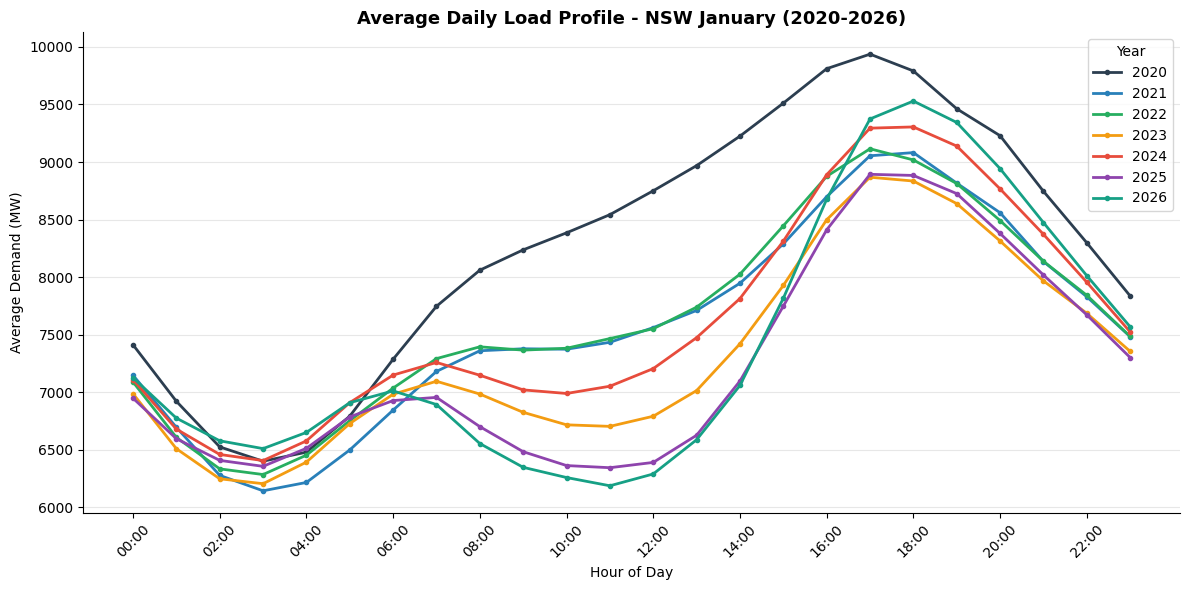

In [12]:
hourly = df_clean.groupby(['year','hour'])['TOTALDEMAND'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2c3e50','#2980b9','#27ae60','#f39c12','#e74c3c','#8e44ad','#16a085']

for i, year in enumerate(years):
    data = hourly[hourly['year'] == year]
    ax.plot(data['hour'], data['TOTALDEMAND'], marker='o', markersize=3,
            label=str(year), color=colors[i], linewidth=2)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Demand (MW)')
ax.set_title('Average Daily Load Profile - NSW January (2020-2026)', fontweight='bold', fontsize=13)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.legend(title='Year', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/daily_load_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Electricity Price Analysis

 year  avg_price  peak_price  median_price
 2020 152.304563    14700.00        50.405
 2021  38.839543      299.99        35.770
 2022  77.167739      299.99        76.575
 2023  94.394300     1254.85        94.515
 2024  81.173880    11781.97        59.990
 2025  75.743449    14028.17        76.000
 2026  67.221123    11938.05        57.060


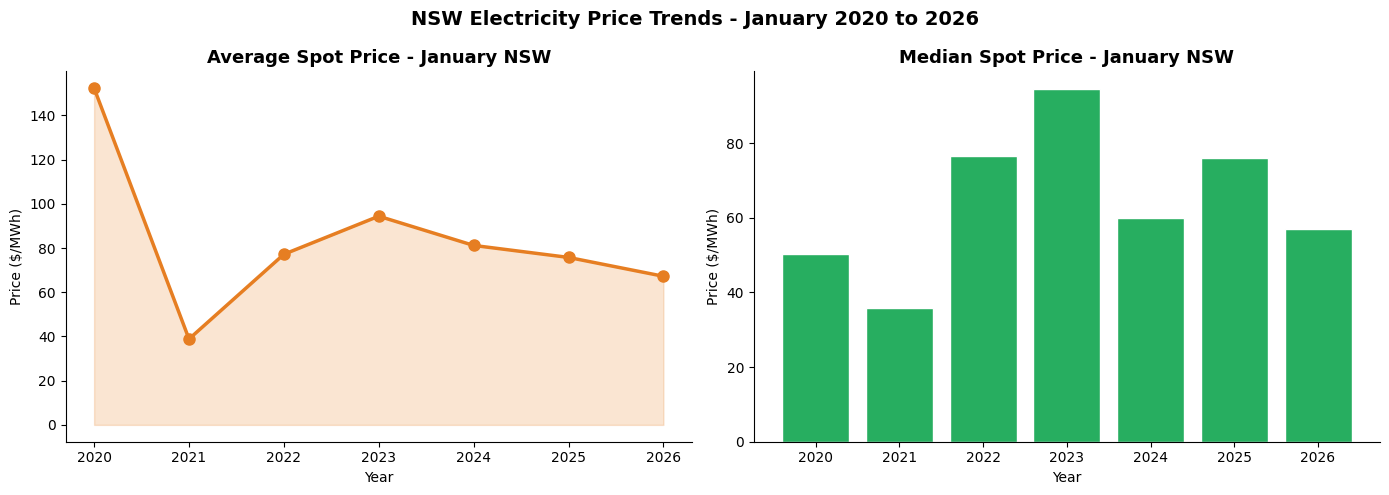

In [13]:
price_yearly = df_clean.groupby('year').agg(
    avg_price=('RRP', 'mean'),
    peak_price=('RRP', 'max'),
    median_price=('RRP', 'median')
).reset_index()

print(price_yearly.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(price_yearly['year'], price_yearly['avg_price'],
             marker='o', color='#e67e22', linewidth=2.5, markersize=8)
axes[0].fill_between(price_yearly['year'], price_yearly['avg_price'],
                      alpha=0.2, color='#e67e22')
axes[0].set_title('Average Spot Price - January NSW', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Price ($/MWh)')
axes[0].set_xlabel('Year')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(price_yearly['year'], price_yearly['median_price'],
            color='#27ae60', edgecolor='white')
axes[1].set_title('Median Spot Price - January NSW', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Price ($/MWh)')
axes[1].set_xlabel('Year')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('NSW Electricity Price Trends - January 2020 to 2026', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/price_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Demand vs Price Relationship

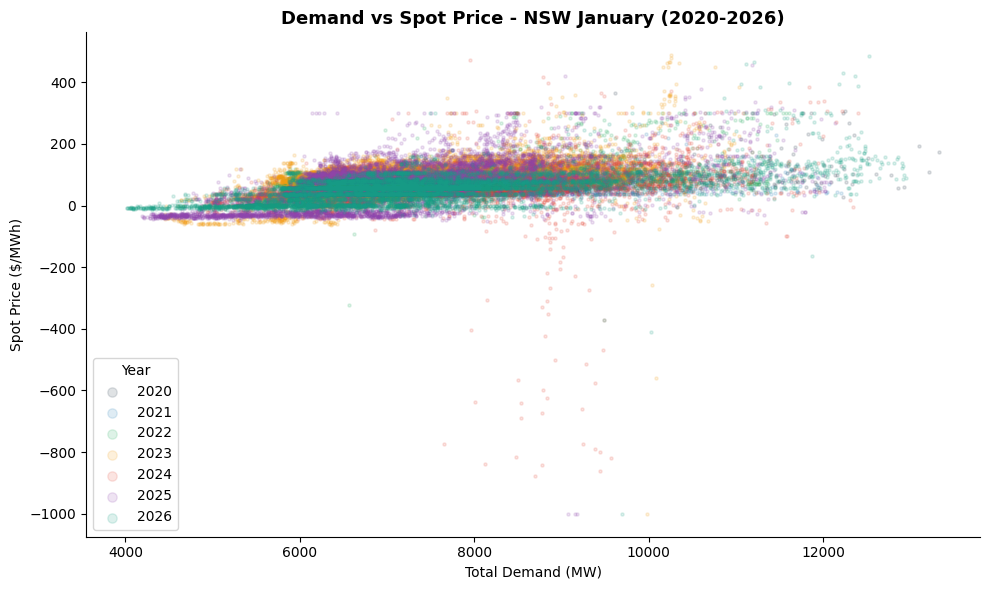

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2c3e50','#2980b9','#27ae60','#f39c12','#e74c3c','#8e44ad','#16a085']

for i, year in enumerate(years):
    subset = df_clean[(df_clean['year'] == year) & (df_clean['RRP'] < 500)]
    ax.scatter(subset['TOTALDEMAND'], subset['RRP'],
               alpha=0.15, s=5, color=colors[i], label=str(year))

ax.set_xlabel('Total Demand (MW)')
ax.set_ylabel('Spot Price ($/MWh)')
ax.set_title('Demand vs Spot Price - NSW January (2020-2026)', fontweight='bold', fontsize=13)
ax.legend(title='Year', fontsize=10, markerscale=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/demand_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Price Spike Analysis (High Stress Events)

Price spike events (>$300/MWh) by year:
 year  spike_count
 2020           24
 2023           43
 2024           75
 2025           36
 2026           43


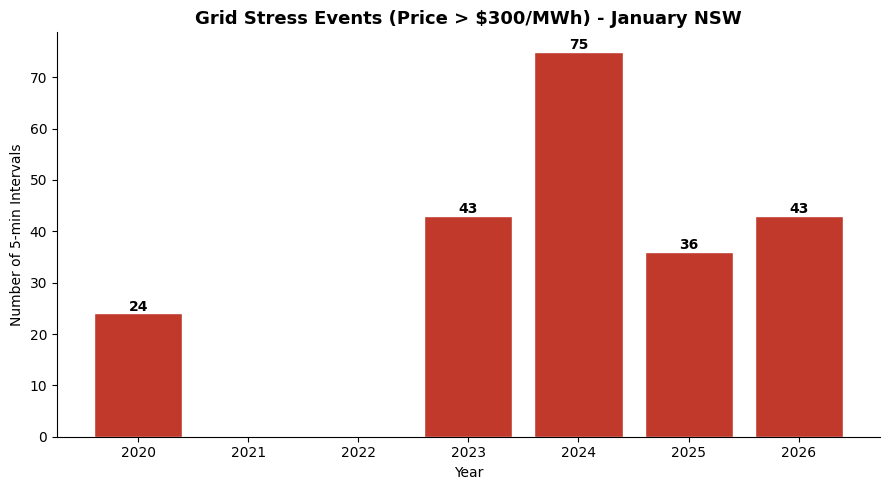

In [15]:
# Price spikes > $300/MWh indicate grid stress events
spike_threshold = 300
spikes = df_clean[df_clean['RRP'] > spike_threshold].groupby('year').size().reset_index(name='spike_count')

print('Price spike events (>$300/MWh) by year:')
print(spikes.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(spikes['year'], spikes['spike_count'], color='#c0392b', edgecolor='white')
ax.set_title('Grid Stress Events (Price > $300/MWh) - January NSW', fontweight='bold', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Number of 5-min Intervals')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, row in spikes.iterrows():
    ax.text(row['year'], row['spike_count'] + 0.5, str(row['spike_count']), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/price_spikes.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Key Insights & Grid Planning Implications

In [16]:
peak = yearly.loc[yearly['peak_demand'].idxmax()]
price_high = price_yearly.loc[price_yearly['avg_price'].idxmax()]
price_low = price_yearly.loc[price_yearly['avg_price'].idxmin()]

print('=== KEY FINDINGS FOR GRID PLANNING ===')
print()
print(f'1. PEAK DEMAND')
print(f'   Highest January peak: {peak["peak_demand"]:.0f} MW in {peak["year"]}')
print()
print(f'2. PRICE VOLATILITY')
print(f'   Highest avg price: ${price_high["avg_price"]:.2f}/MWh in {price_high["year"]}')
print(f'   Lowest avg price:  ${price_low["avg_price"]:.2f}/MWh in {price_low["year"]}')
print()
print(f'3. DAILY LOAD SHAPE')
print(f'   Morning ramp: demand rises sharply from ~06:00')
print(f'   Evening peak: consistently highest demand between 17:00-20:00')
print(f'   This pattern highlights the critical need for dispatchable')
print(f'   capacity and transmission infrastructure during peak windows.')
print()
print(f'4. INFRASTRUCTURE IMPLICATIONS FOR TRANSGRID')
print(f'   Demand volatility across years underscores the need for')
print(f'   robust transmission capacity to handle extreme summer peaks.')
print(f'   Price spikes signal periods of grid stress where additional')
print(f'   interconnector capacity or storage could reduce consumer costs.')

=== KEY FINDINGS FOR GRID PLANNING ===

1. PEAK DEMAND
   Highest January peak: 13330 MW in 2020.0

2. PRICE VOLATILITY
   Highest avg price: $152.30/MWh in 2020.0
   Lowest avg price:  $38.84/MWh in 2021.0

3. DAILY LOAD SHAPE
   Morning ramp: demand rises sharply from ~06:00
   Evening peak: consistently highest demand between 17:00-20:00
   This pattern highlights the critical need for dispatchable
   capacity and transmission infrastructure during peak windows.

4. INFRASTRUCTURE IMPLICATIONS FOR TRANSGRID
   Demand volatility across years underscores the need for
   robust transmission capacity to handle extreme summer peaks.
   Price spikes signal periods of grid stress where additional
   interconnector capacity or storage could reduce consumer costs.


## Conclusions

- NSW January demand shows significant year-to-year variation driven by temperature extremes.
- The evening peak (17:00-20:00) is the most critical window for grid stability and transmission planning.
- Price spikes reveal periods of genuine grid stress, highlighting infrastructure gaps.
- Trends in average demand and pricing inform long-term transmission investment decisions relevant to Transgrid's network planning.
- Data sourced directly from AEMO's NEM aggregated price and demand dataset.
